# 02 · Batch correction with scVI

Starting from the chromosome-annotated snRNA data (notebook 01): drop X/Y genes, select highly
variable genes, integrate across `sex` batches with scVI, and save the batch-normalized expression.

`include_mer` (read from the `INCLUDE_MER` env var) toggles whether the MERFISH panel genes are also kept.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata
import scvi
from sklearn.cluster import KMeans
from scipy.stats import ranksums

sys.path.append('/root/capsule/code/')
from utils import get_paths

sc.settings.seed = 1
print("Last run with scvi-tools version:", scvi.__version__)

Last run with scvi-tools version: 1.3.3


# we want to get the normalized expressions after batchcorrections
- we will not include the QC steps for now

In [ ]:
# include_mer is read from the INCLUDE_MER environment variable so this notebook
# can be run twice (with/without MERFISH genes) from the `run` script.
# Defaults to False when the env var is unset (e.g. interactive runs).
include_mer = os.environ.get("INCLUDE_MER", "False").strip().lower() in ("true", "1", "yes")
print(f"include_mer = {include_mer}")

In [ ]:
dataloc = "/scratch/snRNAseq_LCNE_with_chrom.h5ad"
adata_sc_orig = sc.read_h5ad(dataloc)
adata_sc_orig.obs['actualsex'].value_counts()

actualsex
M    2577
F    2291
Name: count, dtype: int64

## removing  XY genes (keeping the nan and mitochondria genes) 

In [3]:
mask_xy = adata_sc_orig.var["chromosome"].isin(["X",'Y'])
# mask_mt = adata_sc_orig.var["chromosome"].isin(["MT"])
# mask_nan_chrom = adata_sc_orig.var["chromosome"].isna()
# mask_xy_or_nan_or_mt = mask_xy | mask_nan_chrom | mask_mt
mask_xy_or_nan_or_mt = mask_xy 

print(adata_sc_orig.shape[1],'before removing genes')
adata_sc_orig = adata_sc_orig[:, ~mask_xy_or_nan_or_mt.fillna(False)].copy()
print(adata_sc_orig.shape[1],'after removing genes')

29617 before removing genes
29200 after removing genes


## Optionally keep the MERFISH panel genes
Load the MERFISH gene panel and keep only those present in the snRNA data (many are dropped because
they sit on X/Y). These are unioned with the HVGs later when `include_mer=True`.

In [4]:

# MERFISH gene panel path resolved via utils.get_paths() (reads config.toml).
paths = get_paths()
merfish_panel_csv = (paths['merfish_metadata']
                     / 'MouseC_C1' / 'analyzed_data'
                     / 'VS6MsBrain_C1_VS6libary_V3_LH_03-14-21' / 'region_1' / 'cell_by_gene.csv')
allgenesdf = pd.read_csv(merfish_panel_csv)
merfishgenenames = [col for col in allgenesdf.columns[1:] if "Blank" not in col]

# print out genes not in the snRNA (note lots of them are removed bc they were on X/Y chromosomes)
[print(a) for a in merfishgenenames if a not in list(adata_sc_orig.var_names) ]


merfishgenenames = [a for a in merfishgenenames if a in list(adata_sc_orig.var_names) ]  # there are a fwe genes that are not existent on scRNA

adata_sc_orig.raw = adata_sc_orig.copy()


C130060K24Rik
Il1rapl2
Htr2c


### QC metrics: mitochondrial & ribosomal content per sample

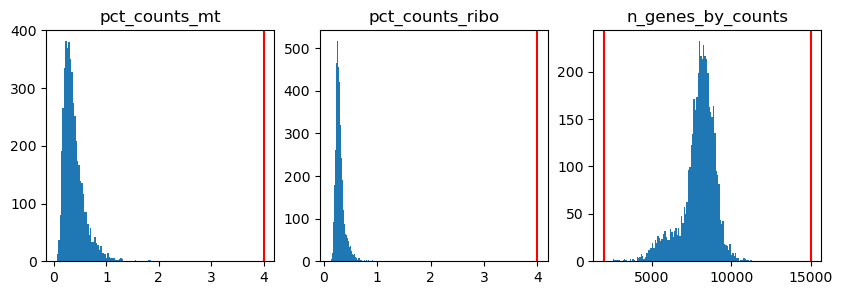

In [5]:
adata_sc_orig.var["mt"] = adata_sc_orig.var_names.str.startswith("mt-")
adata_sc_orig.var["ribo"] = adata_sc_orig.var_names.str.startswith(("Rps", "Rpl")) # no Mt
sc.pp.calculate_qc_metrics(adata_sc_orig, qc_vars=["mt", "ribo"], percent_top=None, log1p=False, inplace=True)

mt_thre = 4
ribo_thre = 4
totalcounts_thre = (2000,15000)

plt.figure(figsize = (10,3))
plt.subplot(1,3,1);
plt.hist(adata_sc_orig.obs['pct_counts_mt'].values.flatten(), bins = 100);
plt.axvline(mt_thre, color = 'red')
plt.title('pct_counts_mt')

plt.subplot(1,3,2);
plt.hist(adata_sc_orig.obs['pct_counts_ribo'].values.flatten(), bins = 100);
plt.axvline(ribo_thre, color = 'red')
plt.title('pct_counts_ribo')

plt.subplot(1,3,3);
plt.hist(adata_sc_orig.obs['n_genes_by_counts'].values.flatten(), bins = 100);
plt.axvline(totalcounts_thre[0], color = 'red');
plt.axvline(totalcounts_thre[1], color = 'red')
plt.title('n_genes_by_counts');

# two ways to do the HVG
1. CPM with seurat v3 (normalized) - default 
2. log CPM with seurat 

In [6]:
sc.pp.highly_variable_genes(adata_sc_orig, n_top_genes=1500,
                            flavor="seurat_v3",#batch_key="sex",
                            subset=False)
hvg_genes = sorted(
    set(
        adata_sc_orig.var_names[adata_sc_orig.var["highly_variable"]].tolist()
        + ["Dbh", "Th"]
    )
)

assert len(hvg_genes) == len(set(hvg_genes))
if include_mer:
    genes_to_keep = sorted(list(set(hvg_genes) | set(merfishgenenames) ))
else:
    genes_to_keep = sorted(list(set(hvg_genes)))  # Also sort this one
print("number of genes to keep:", len(genes_to_keep))  # ~1769 with MERFISH, ~1500 without

number of genes to keep: 1502


In [7]:

genes_of_interest = ["Dbh", "Th", "Shox2", "Pdyn","Htr2a","Htr2b"]
in_hvg = [g for g in genes_of_interest if g in hvg_genes]
not_in_hvg = [g for g in genes_of_interest if g not in hvg_genes]
print("In HVG list:", in_hvg)
print("Missing from HVG list:", not_in_hvg)

In HVG list: ['Dbh', 'Th', 'Shox2', 'Htr2a']
Missing from HVG list: ['Pdyn', 'Htr2b']


In [8]:
# save raw, and change the observations columns etc
raw_adata = adata_sc_orig.copy()
adata_sc = raw_adata[:, genes_to_keep].copy()
adata_sc.raw = raw_adata[adata_sc.obs_names, :].copy()
totalcounts = np.sum(adata_sc.X, -1)
adata_sc.obs['totalcounts']=totalcounts
def batch_flag(x):
    # 1 for concatenated long strings, 0 for simple M/F
    return 1 if ';' in x else 2
adata_sc.obs['experimental_batch_id'] = adata_sc.obs['sex'].apply(batch_flag).astype('O')
adata_sc.X = adata_sc.X.tocsr() # do this for the faster scvi implementation!

In [ ]:
# --- Canonical "island" (outlier) cell definition ---------------------------
# The island cells are discarded at save time. To keep the dropped-cell set (and
# therefore the final n_obs) identical whether or not the MERFISH panel genes are
# included, the island is defined ONCE, from the HVG-only embedding, and reused:
#
#   * include_mer=False -> the current embedding already IS the HVG-only one, so
#     the island is detected below exactly as before, and its barcodes cached.
#   * include_mer=True  -> those cached barcodes are reused instead of
#     re-detecting on the (gene-panel-dependent) MERFISH-augmented embedding.
#
# The `run` script executes INCLUDE_MER=False before INCLUDE_MER=True, so the
# cache is always populated before the True run needs it. This leaves the
# include_mer=False pipeline (and its output h5ad) completely unchanged.
island_cache = os.path.join("/root/capsule/results/snRNAseq",
                            "canonical_island_barcodes.csv")
os.makedirs(os.path.dirname(island_cache), exist_ok=True)

# run scvi for the integrations

In [ ]:
scvi.settings.seed = 421
scvi.model.SCVI.setup_anndata(adata_sc, batch_key='sex')
model = scvi.model.SCVI(adata_sc, n_layers=1, n_latent=4, gene_likelihood="zinb")
model.train(max_epochs=400)#,early_stopping=True)#,early_stopping_patience=45)

In [ ]:
SCVI_LATENT_KEY = "X_scVI"
adata_sc.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

In [ ]:
# scVI latent-space mean per dimension - quick reproducibility check across seeds.
# seed 42 (with barmer): -0.02546425, -0.04029592, -0.09200841,  0.02213329
# seed 4  (no barmer):   -0.01065198, -0.03663757, -0.02210931, -0.08312064
print("scVI latent mean per dim:", np.mean(adata_sc.obsm[SCVI_LATENT_KEY], 0))

In [ ]:
sc.pp.neighbors(adata_sc, use_rep=SCVI_LATENT_KEY, n_neighbors=15, random_state=1)
sc.tl.umap(adata_sc,random_state=210, min_dist=.5)  

In [ ]:
ax = sc.pl.umap(
    adata_sc,color=["sex",'actualsex'],
    ncols=3,show = False)
for a in ax:
    a.set_aspect('equal')

# investigate further on the small island 

In [ ]:
X = adata_sc.obsm["X_umap"]

if not include_mer:
    # HVG-only embedding: detect the island exactly as the original pipeline did
    # (smallest of 50 KMeans clusters on the UMAP), then cache the barcodes so
    # the include_mer=True run reuses the same cells.
    kmeans = KMeans(n_clusters=50, random_state=0).fit(X)
    labels = kmeans.labels_

    sizes = np.bincount(labels)
    island_label = sizes.argmin()

    adata_sc.obs["umap_island"] = pd.Categorical(
        np.where(labels == island_label, "island", "main")
    )

    island_barcodes = adata_sc.obs_names[adata_sc.obs["umap_island"] == "island"].astype(str)
    pd.DataFrame({"barcode": island_barcodes}).to_csv(island_cache, index=False)
    print(f"Detected {len(island_barcodes)} island cells (HVG-only); cached -> {island_cache}")
else:
    # MERFISH-augmented embedding: reuse the canonical island from the HVG-only
    # run so the dropped cells (and n_obs) match the include_mer=False output.
    if not os.path.exists(island_cache):
        raise FileNotFoundError(
            f"{island_cache} not found. Run this notebook once with INCLUDE_MER=False "
            "first so the canonical island cells are defined from the HVG-only embedding."
        )
    island_barcodes = pd.read_csv(island_cache)["barcode"].astype(str)
    adata_sc.obs["umap_island"] = pd.Categorical(
        np.where(adata_sc.obs_names.isin(list(island_barcodes)), "island", "main")
    )
    print(f"Reused {len(island_barcodes)} canonical island cells from {island_cache}")

# quick check
a=sc.pl.umap(adata_sc, color="umap_island", show = False)
a.set_aspect('equal')

# 3) DE: island vs main
sc.tl.rank_genes_groups(
    adata_sc,
    groupby="umap_island",
    groups=["island"],
    reference="main",
    method="wilcoxon",
)

sc.pl.rank_genes_groups(adata_sc, n_genes=20, sharey=False)

print("cells in the island:", (adata_sc.obs["umap_island"] == "island").sum())

In [ ]:
rg = adata_sc.uns["rank_genes_groups"]
topgene = pd.DataFrame({
    k: rg[k]["island"] for k in ["names", "scores", "pvals_adj"]
}).head(8)["names"].tolist()

ax = sc.pl.umap(
    adata_sc,
    color=topgene,sort_order=True,
    ncols=4,cmap = 'Reds', show = False
)
for a in ax: a.set_aspect('equal')

In [ ]:
gene = "Shox2"
if adata_sc.raw is not None and gene in adata_sc.raw.var_names:
    expr = adata_sc.raw[:, gene].X
else:
    expr = adata_sc[:, gene].X
expr = np.asarray(expr.todense()).ravel()
ds   = adata_sc.obs["doublet_score"].values


In [ ]:
is_island = adata_sc.obs["umap_island"] == "island"

plt.figure(figsize=(4, 4))
plt.scatter(np.log1p(expr[~is_island]), ds[~is_island], s=5, alpha=0.3, label="main")
plt.scatter(np.log1p(expr[is_island]),  ds[is_island],  s=8, alpha=0.8, label="island")
plt.xlabel("log1p(Shox2 expression)")
plt.ylabel("doublet_score")
plt.legend()
plt.tight_layout()
plt.show()

# check the mean doublet scores difference

In [ ]:
print("mean doublet score - main:  ", ds[~is_island].astype(float).mean())
print("mean doublet score - island:", ds[is_island].astype(float).mean())

In [ ]:

ax =sc.pl.umap(
    adata_sc,
    color=['Dbh','Th','Shox2','Tacr3','Trhr'],
    ncols=8,cmap = 'Reds', s = 10, show = False
)
for a in ax: a.set_aspect('equal')

In [ ]:

num_cols = adata_sc.obs.select_dtypes(include="number").columns

summary = (adata_sc.obs.groupby("umap_island")[num_cols].median().T)

summary["delta"] = summary["island"] - summary["main"]
summary.sort_values("delta", ascending=False).head(15)


In [ ]:
stats = []
for c in num_cols:
    x = adata_sc.obs.loc[adata_sc.obs.umap_island=="island", c]
    y = adata_sc.obs.loc[adata_sc.obs.umap_island=="main", c]
    if x.nunique() > 1 and y.nunique() > 1:
        stats.append((c, ranksums(x, y).pvalue))

pd.DataFrame(stats, columns=["col", "p"]).sort_values("p").head(15)

# get the batch average normalized expression counts
- Denoised expression with batch “removed”

In [ ]:
all_batches = model.adata_manager.get_state_registry("batch").categorical_mapping.tolist()
print("scVI batch categories (averaged over for denoised expression):", all_batches)

In [ ]:
X_hat_avg = model.get_normalized_expression(
    adata=adata_sc,
    transform_batch=all_batches,
    library_size= 1, # we wont change this to 1e+6 here for now
    return_numpy=False
)
adata_sc_BN = anndata.AnnData(X_hat_avg.copy())
adata_sc_BN.obs = adata_sc.obs.copy()
adata_sc_BN.obsm = adata_sc.obsm.copy()
adata_sc_BN.var = adata_sc.var.copy()

# save 
- the normalized counts are saved as `BN` layer
- for now we keep library size 1


### discard the small "island" cells, keeping only the main population.
The island is detected once from the HVG-only run (`include_mer=False`) and cached to `canonical_island_barcodes.csv`; the `include_mer=True` run reuses those same barcodes. So the same cells are dropped in both cases — the two outputs differ only in genes, not in cells.


In [ ]:
cpm_scl= 1
adata_sc.layers["BN"] = X_hat_avg*cpm_scl


path = "/root/capsule/results/snRNAseq"
if not os.path.exists(path):
    os.makedirs(path)
    print(f"Created: {path}")
else:
    print(f"Already exists: {path}")

filename = 'snRNAseq_LCNE_BN_d4_merbar_1-5k.h5ad' if include_mer else 'snRNAseq_LCNE_BN_d4_1-5k.h5ad' 
adata_sc.obs['experimental_batch_id'] = adata_sc.obs['experimental_batch_id'].astype(str)

adata_sc_final = adata_sc[adata_sc.obs["umap_island"] != "island"].copy()
adata_sc_final.write(path+f"/{filename}")

print('data shape final:', adata_sc_final.shape)

